Displaying SIFT Features for Image 1...


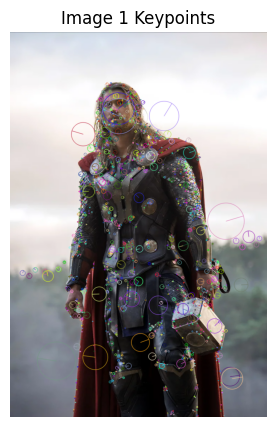

Displaying Matched Features...


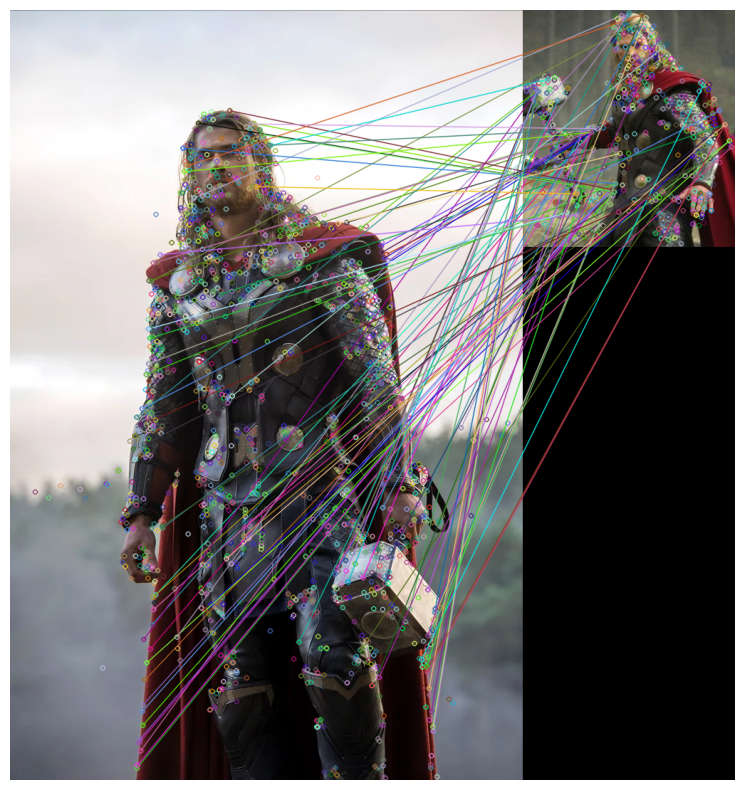

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the built-in OpenCV SIFT detector
sift = cv2.SIFT_create()

# 2. Assign your image paths directly (No input() required)
image_path1 = ("Thor.jpg")
image_path2 = ("Thor2.jpg")

Image1 = cv2.imread(image_path1)
Image2 = cv2.imread(image_path2)

# Ensure images were actually loaded properly
if Image1 is None or Image2 is None:
    raise FileNotFoundError(
        "Could not load one of the images. Please check your file paths!"
    )

# 3. Convert images to grayscale
Image1_gray = cv2.cvtColor(Image1, cv2.COLOR_BGR2GRAY)
Image2_gray = cv2.cvtColor(Image2, cv2.COLOR_BGR2GRAY)

# 4. Extract SIFT features using native OpenCV methods
Image1_key_points, Image1_descriptors = sift.detectAndCompute(
    Image1_gray, None
)
Image2_key_points, Image2_descriptors = sift.detectAndCompute(
    Image2_gray, None
)

print("Displaying SIFT Features for Image 1...")
# Replaced custom 'showing_sift_features' with native OpenCV drawing
sift_image1 = cv2.drawKeypoints(
    Image1,
    Image1_key_points,
    None,
    flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS,
)
plt.figure(figsize=(10, 5))
plt.imshow(cv2.cvtColor(sift_image1, cv2.COLOR_BGR2RGB))
plt.title("Image 1 Keypoints")
plt.axis("off")
plt.show()

# 5. Match descriptors using Brute-Force Matcher
norm = cv2.NORM_L2
bruteForce = cv2.BFMatcher(norm)
matches = bruteForce.match(Image1_descriptors, Image2_descriptors)

# Sort matches by distance (best matches first)
matches = sorted(matches, key=lambda match: match.distance)

# 6. Draw top 100 matches
matched_img = cv2.drawMatches(
    Image1,
    Image1_key_points,
    Image2,
    Image2_key_points,
    matches[:100],
    Image2.copy(),
)

# 7. Display the final matched images
print("Displaying Matched Features...")
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(matched_img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()